In [1]:
import numpy as np
import matplotlib.pyplot as plt

import sys, os
sys.path.append(os.path.expanduser('~/Desktop/Pangal'))

from pangal.pangal import PanGal
from pangal.pfitter import PFitter

from build_boissier import truncated_boissier_sfh, truncated_boissier_sed, build_boissier_SEDs, load_spectrum_models_from_fits


In [2]:
specs = load_spectrum_models_from_fits(filename='V_160_R_7_Z_017.fit')

In [3]:
specs[0].header

XTENSION= 'BINTABLE'           / binary table extension                         
BITPIX  =                    8 / array data type                                
NAXIS   =                    2 / number of array dimensions                     
NAXIS1  =                   12 / length of dimension 1                          
NAXIS2  =                16688 / length of dimension 2                          
PCOUNT  =                    0 / number of group parameters                     
GCOUNT  =                    1 / number of groups                               
TFIELDS =                    3 / number of table fields                         
TTYPE1  = 'FLUX    '                                                            
TFORM1  = 'E       '                                                            
TTYPE2  = 'FLUX_YOUNG'                                                          
TFORM2  = 'E       '                                                            
TTYPE3  = 'FLUX_OLD'        

In [4]:
fitter = PFitter(specs,
                 model_pars=['Q_AGE','TAU_Q','BURST','METAL'],
                )

Initializing PFitter object
   Model parameters: Q_AGE, TAU_Q, BURST, METAL

 Pre-computed model grid:
   - Q_AGE: 4 values, min=10, max=40
   - TAU_Q: 4 values, min=2, max=16
   - BURST: 2 values, min=0, max=10
   - METAL: 2 values, min=0.008, max=0.014


Loading nebular lines templates from  nebular_Byler_mist_2018.lines
 Emission line metallicity requested 0.0017, found 0.0020
Tabulated values for ionized gas age (Myr): [ 0.5  1.   2.   3.   4.   5.   6.   7.  10. ]
Tabulated values for ionization coefficient: [-4.  -3.5 -3.  -2.5 -2.  -1.5 -1. ]
Loading of nebular lines templates completed.
Tabulated alpha values from 'alpha_dh02.dat': [0.0625 0.125  0.1875 0.25   0.3125 0.375  0.4375 0.5    0.5625 0.625
 0.6875 0.75   0.8125 0.875  0.9375 1.     1.0625 1.125  1.1875 1.25
 1.3125 1.375  1.4375 1.5    1.5625 1.625  1.6875 1.75   1.8125 1.875
 1.9375 2.     2.0625 2.125  2.1875 2.25   2.3125 2.375  2.4375 2.5
 2.5625 2.625  2.6875 2.75   2.8125 2.875  2.9375 3.     3.0625 3.125
 3.18

In [5]:
mock_spec = fitter.synthetic_spectrum(
            multi_component=True,
            Q_AGE=30,
            TAU_Q=12,
            BURST=0,
            METAL=0.014,
            fesc=0.5,
            av=1.2,
            av_ext= 0.094,
            alpha=3.5,
            m_star=9.2,
            ion_gas=-3.94,
            age_gas=13,
            redshift=0.02,
            dl=104,  # Luminosity distance in Mpc (assumed)
        )

/home/utente/Desktop/Pangal/pangal/spectrum.py:105: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  norm_int, _ = quad(lambda l: trans_curve(l), lmin, lmax)


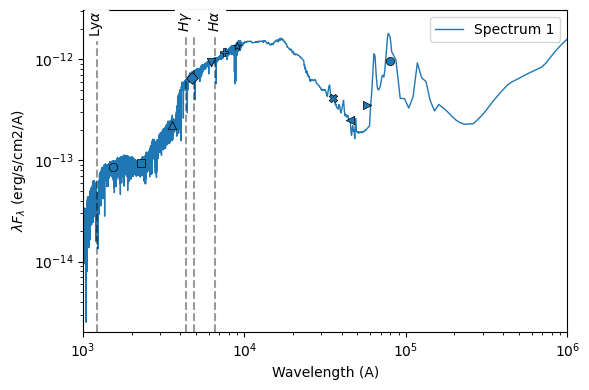

In [6]:

bands=['galex_fuv','galex_nuv','sdss_u','sdss_g','sdss_r','sdss_i','sdss_z','spitzer_irac_1','spitzer_irac_2','spitzer_irac_3','spitzer_irac_4']

mock_spec.plot(per_wavelength=True,phot_points=bands,phot_legend=True,
              winf=1000,wsup=1e6,show_H_lines=True)

phot_points = mock_spec.get_phot(bands=bands,units='mJy')

for b in bands: 
    value, error = phot_points.data[b]
    phot_points.data[b] = (value, 0.1 * value)


In [11]:
phot_points.print

,Value,Error,SNR
Band,,,
galex_fuv,0.004393,0.000439,10.0
galex_nuv,0.007295,0.000729,10.0
sdss_u,0.026641,0.002664,10.0
sdss_g,0.101132,0.010113,10.0
sdss_r,0.193062,0.019306,10.0
sdss_i,0.290836,0.029084,10.0
sdss_z,0.404038,0.040404,10.0
spitzer_irac_1,0.487174,0.048717,10.0
spitzer_irac_2,0.372613,0.037261,10.0


In [15]:
custom_prior = {
    'av':     {'type':'uniform', 'low':0.0,    'high':0.2},
    'alpha':  {'type':'uniform', 'low':1.5,    'high':3.5}
}

In [16]:
results = fitter.run_fit(phot=phot_points, 
                         bands=bands, 
                         fix_pars={'ion_gas':-3.94,'age_gas':13,'fesc':0.5,'m_star':9.2,'av_ext':0,'BURST':0,'METAL':0.014},
                        nlive=100,
                        dlogz=0.1,
                        custom_priors=custom_prior)


Using the following photometric filters: galex_fuv, galex_nuv, sdss_u, sdss_g, sdss_r, sdss_i, sdss_z, spitzer_irac_1, spitzer_irac_2, spitzer_irac_3, spitzer_irac_4
Redshift not provided and not found in phot dictionary or spectrum header. Set to 0.

Priors:
  - Q_AGE: Uniform(10, 40)
  - TAU_Q: Uniform(2, 16)
  - BURST: Uniform(0, 10)
  - METAL: Uniform(0.008, 0.014)
  - av: Uniform(0.0, 0.2)
  - alpha: Uniform(1.5, 3.5)
Initializing live points
Exception while calling prior_transform function:
  params: [0.79371999 0.0695941  0.66626568 0.42016856]
  args: []
  kwargs: {}
  exception:


Traceback (most recent call last):
  File "/home/utente/anaconda3/envs/cigale/lib/python3.11/site-packages/dynesty/dynesty.py", line 913, in __call__
    return self.func(np.asarray(x).copy(), *self.args, **self.kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/utente/Desktop/Pangal/pangal/pfitter.py", line 318, in prior_transform
    x[i] = prior['low'] + u[i] * (prior['high'] - prior['low'])
                          ~^^^
IndexError: index 4 is out of bounds for axis 0 with size 4


╭─────────────────────────────── Traceback (most recent call last) ────────────────────────────────╮
│ in <module>:1                                                                                    │
│                                                                                                  │
│ ❱ 1 results = fitter.run_fit(phot=phot_points,                                                   │
│   2 │   │   │   │   │   │    bands=bands,                                                        │
│   3 │   │   │   │   │   │    fix_pars={'ion_gas':-3.94,'age_gas':13,'fesc':0.5,'m_star':9.2,     │
│   4 │   │   │   │   │   │   nlive=100,                                                           │
│                                                                                                  │
│ /home/utente/Desktop/Pangal/pangal/pfitter.py:145 in run_fit                                     │
│                                                                                                  │
│   142 │   │   prior_transform = self.make_prior_transform(custom_priors)                         │
│   143 │   │                                                                                      │
│   144 │   │   print("Initializing live points")                                                  │
│ ❱ 145 │   │   sampler = NestedSampler(log_likelihood, prior_transform, ndim=len(free_pars),nli   │
│   146 │   │                                                                                      │
│   147 │   │   # Run the nested sampling                                                          │
│   148 │   │   sampler.run_nested(dlogz=dlogz, print_progress=True)                               │
│                                                                                                  │
│ /home/utente/anaconda3/envs/cigale/lib/python3.11/site-packages/dynesty/dynesty.py:680 in        │
│ __new__                                                                                          │
│                                                                                                  │
│   677 │   │   │   kwargs['grad'] = grad                                                          │
│   678 │   │   │   kwargs['compute_jac'] = compute_jac                                            │
│   679 │   │                                                                                      │
│ ❱ 680 │   │   live_points, logvol_init, init_ncalls = _initialize_live_points(                   │
│   681 │   │   │   live_points,                                                                   │
│   682 │   │   │   ptform,                                                                        │
│   683 │   │   │   loglike,                                                                       │
│                                                                                                  │
│ /home/utente/anaconda3/envs/cigale/lib/python3.11/site-packages/dynesty/dynamicsampler.py:437 in │
│ _initialize_live_points                                                                          │
│                                                                                                  │
│    434 │   │   │   │   cur_live_v = M(prior_transform, np.asarray(cur_live_u))                   │
│    435 │   │   │   else:                                                                         │
│    436 │   │   │   │   cur_live_v = map(prior_transform, np.asarray(cur_live_u))                 │
│ ❱  437 │   │   │   cur_live_v = np.array(list(cur_live_v))                                       │
│    438 │   │   │   cur_live_logl = loglikelihood.map(np.asarray(cur_live_v))                     │
│    439 │   │   │   if blob:                                                                      │
│    440 │   │   │   │   cur_live_blobs = np.array([_.blob for _ in cur_live_logl])                │
│                                                            

In [13]:
results = fitter.run_fit(phot=phot_points, 
                         bands=bands, 
                         fix_pars={'ion_gas':-3.94,'age_gas':13,'fesc':0.5,'m_star':9.2,'av_ext':0.094,},
                        nlive=100,
                        dlogz=0.1,
                        custom_priors=custom_prior)


Using the following photometric filters: galex_fuv, galex_nuv, sdss_u, sdss_g, sdss_r, sdss_i, sdss_z, spitzer_irac_1, spitzer_irac_2, spitzer_irac_3, spitzer_irac_4
Redshift not provided and not found in phot dictionary or spectrum header. Set to 0.

Priors:
  - Q_AGE: Uniform(10, 40)
  - TAU_Q: Uniform(2, 16)
  - BURST: Uniform(0, 10)
  - METAL: Uniform(0.008, 0.014)
  - av: Uniform(0.0, 0.2)
  - alpha: Uniform(1.5, 3.5)
Initializing live points


4243it [02:02, 34.66it/s, +100 | bound: 164 | nc: 1 | ncall: 28148 | eff(%): 15.484 | loglstar:   -inf < -3452.458 <    inf | logz: -3492.374 +/-  0.600 | dlogz:  0.001 >  0.100]


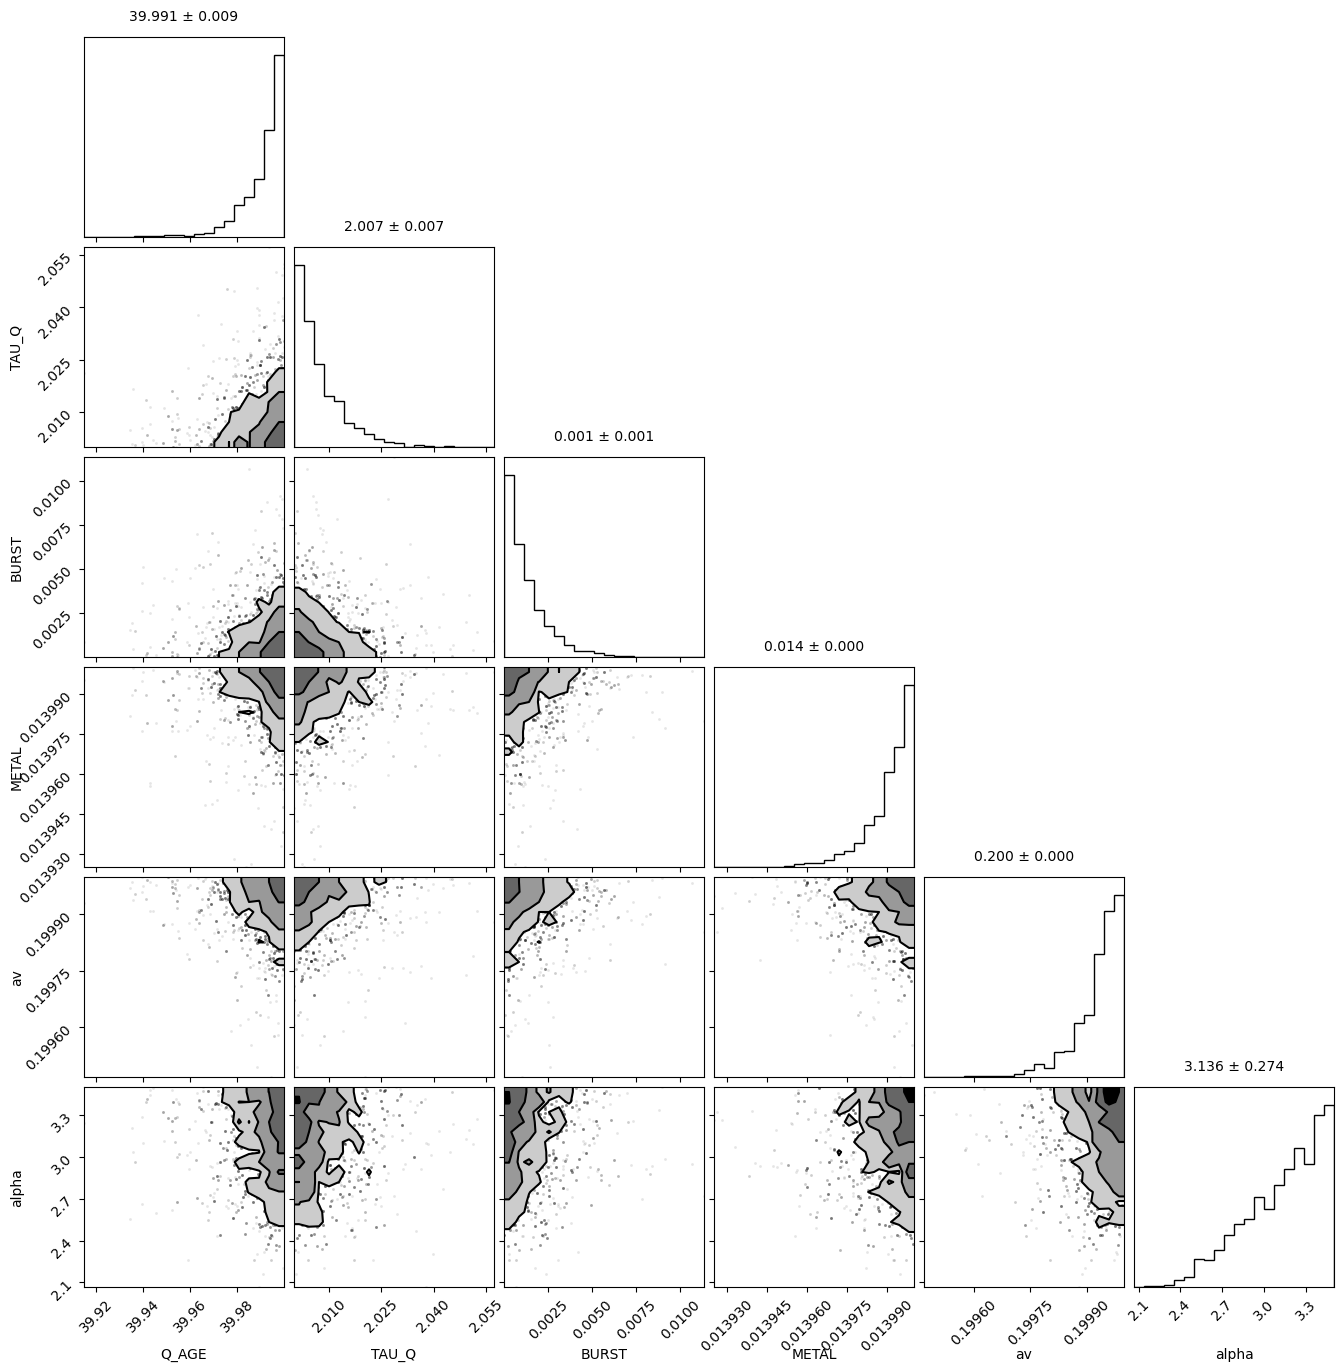

In [14]:
fitter.cornerplot(results)